# Independent Application for Overloaded Vehicle Detection and License Plate Recognition
This section demonstrates how to use the exported Detectron2 model and EasyOCR in a standalone manner, as if in a separate application. It includes all necessary imports and setups from scratch.

In [ ]:
# 1. Install and Import Libraries (as if starting a new environment)

# Mount Google Drive (if not already mounted)
from google.colab import drive
drive.mount('/content/drive')

# Install Detectron2 dependencies (minimal set for inference)
# In a real standalone app, these would be in a requirements.txt and installed via pip.
# For Colab, we'll ensure they are present.
!python -m pip install pyyaml opencv-python matplotlib
!git clone 'https://github.com/facebookresearch/detectron2' &> /dev/null || echo 'Detectron2 already cloned'
import sys, os, distutils.core
sys.path.insert(0, os.path.abspath('./detectron2'))

# Install fvcore (Detectron2 dependency)
!pip install fvcore &> /dev/null || echo 'fvcore already installed'

# Install EasyOCR
!pip install easyocr &> /dev/null || echo 'EasyOCR already installed'

# Import all necessary libraries
import cv2
import json
import os
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import easyocr
import yaml # For loading config file
import torch

# Detectron2 specific imports for inference
from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2.structures import BoxMode

print("All necessary libraries imported and Drive mounted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Detectron2 already cloned
All necessary libraries imported and Drive mounted.


2. Load the Exported Detectron2 Model and Initialize EasyOCR

In [ ]:
# Define the path to the exported model
exported_model_dir = "/content/drive/MyDrive/Data/exported_model"
config_path = os.path.join(exported_model_dir, "config.yaml")
weights_path = os.path.join(exported_model_dir, "model_final.pth")

# Check if files exist
if not os.path.exists(config_path):
    raise FileNotFoundError(f"Config file not found at: {config_path}")
if not os.path.exists(weights_path):
    raise FileNotFoundError(f"Weights file not found at: {weights_path}")

# Load the Detectron2 configuration
cfg = get_cfg()
cfg.merge_from_file(config_path)
cfg.MODEL.WEIGHTS = weights_path
# Lowered the confidence threshold to make the model more sensitive to detections.
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # Set a confidence threshold
cfg.MODEL.DEVICE = "cuda" if torch.cuda.is_available() else "cpu" # Use GPU if available

# Set the number of classes (ensure this matches your training setup)
# Based on your training code, category_id 0 was 'normal_vehicle' and 1 was 'overloaded_vehicle'
# Detectron2 internally adds a background class, so total classes = actual_classes + 1.
# In your training, you set NUM_CLASSES = 2, meaning 2 object classes + 1 background = 3 output classes in the model.
# So we keep it as 2 for Detectron2's NUM_CLASSES parameter.
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 2

# Create a DefaultPredictor
detector_predictor = DefaultPredictor(cfg)

# Define metadata for visualization
# Re-register datasets if not already done in the current session, or manually create metadata
# For a standalone app, you'd typically define these directly or load from a file.
# Here we define them to match the training setup:
vehicle_classes = ["normal_vehicle", "overloaded_vehicle"]
MetadataCatalog.get("vehicle_inference").set(thing_classes=vehicle_classes)
inference_metadata = MetadataCatalog.get("vehicle_inference")

print(f"Detectron2 model loaded from {weights_path} with config {config_path}")

# Initialize EasyOCR reader
easyocr_reader = easyocr.Reader(['ko']) # Load Korean model
print("EasyOCR reader initialized for Korean.")

Detectron2 model loaded from /content/drive/MyDrive/Data/exported_model/model_final.pth with config /content/drive/MyDrive/Data/exported_model/config.yaml
EasyOCR reader initialized for Korean.


In [11]:
def process_image(image_path):
    """
    Loads an image, performs overloaded vehicle detection, and if detected,
    attempts to read license plate using OCR. Displays results.
    """
    print(f"Processing image: {image_path}")
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return

    # Convert image to RGB for matplotlib display
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Perform detection
    outputs = detector_predictor(img)
    instances = outputs["instances"].to("cpu")

    # Visualize detections
    visualizer = Visualizer(img_rgb, metadata=inference_metadata, scale=1.0)
    out = visualizer.draw_instance_predictions(instances)
    img_with_detections = out.get_image()

    overloaded_detected = False
    ocr_text = []

    # Check for 'overloaded_vehicle' (category_id=1)
    for i in range(len(instances)):
        if instances.pred_classes[i] == 1:  # Assuming 1 is 'overloaded_vehicle'
            overloaded_detected = True
            bbox = instances.pred_boxes.tensor[i].numpy()
            xmin, ymin, xmax, ymax = map(int, bbox)

            # Extract potential license plate region (adjust as needed)
            # This is a simple crop. For better results, you might need a dedicated LP detector.
            lp_region = img[ymin:ymax, xmin:xmax]

            if lp_region.size > 0: # Ensure the cropped region is valid
                print("Overloaded vehicle detected. Attempting OCR on detected box...")
                # Perform OCR on the cropped region
                results_ocr = easyocr_reader.readtext(lp_region, detail=0)
                if results_ocr:
                    ocr_text.extend(results_ocr)
                    print(f"OCR results: {', '.join(results_ocr)}")
                else:
                    print("No text detected in the overloaded vehicle region.")
            else:
                print("Detected box for overloaded vehicle is empty or invalid for OCR.")

    # Display results
    plt.figure(figsize=(15, 10))
    plt.imshow(img_with_detections)
    plt.title("Overloaded Vehicle Detection" + (" (Overloaded!)" if overloaded_detected else " (Normal Vehicle)"))
    plt.axis("off")

    if ocr_text:
        plt.text(10, img.shape[0] + 30, f"OCR Result: {', '.join(ocr_text)}",
                 color='red', fontsize=16, backgroundcolor='white')
    plt.show()

    return overloaded_detected, ocr_text

### 4. Demonstration: Simulate GUI interaction

FileUpload(value={}, accept='image/*', description='Upload')

Button(description='Process Image', style=ButtonStyle())

Output()


To test, upload an image using the button above and click 'Process Image'.
You can use images from your Google Drive, for example: /content/drive/MyDrive/Data/validation/source/A01_B01_C04_D05_1123_I04_F10_855_5.jpg


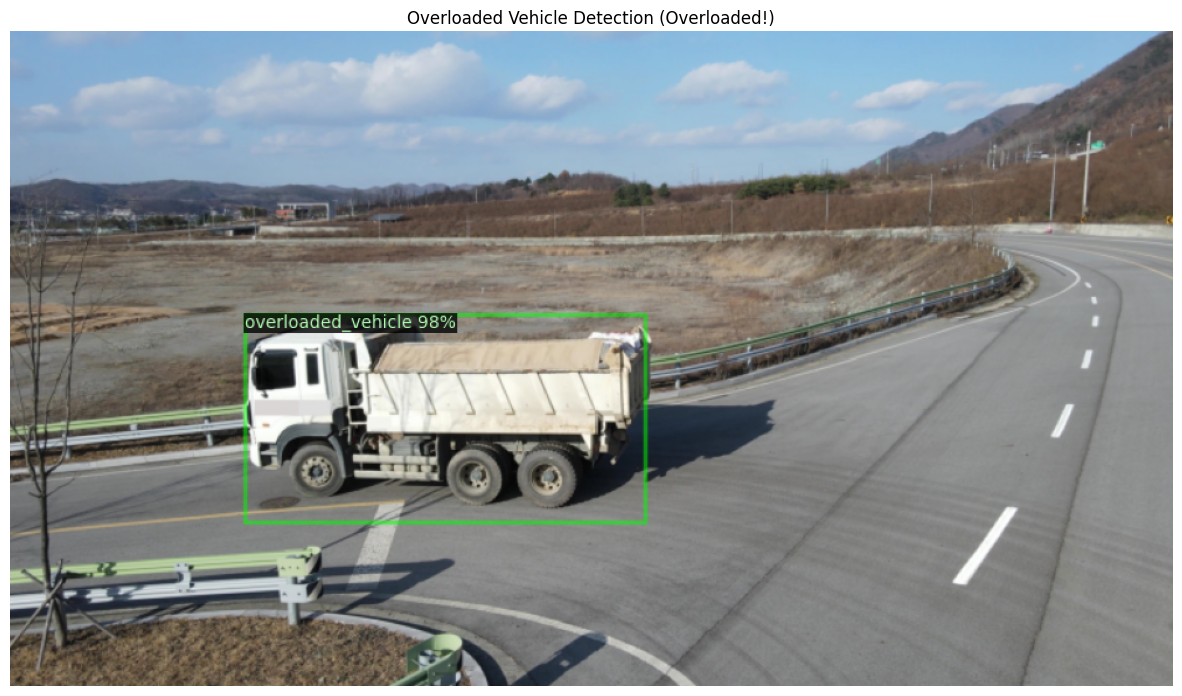


Detected as OVERLOADED VEHICLE. OCR Results: 


In [12]:
from ipywidgets import FileUpload, Button, Output
from IPython.display import display
import io
from PIL import Image

# Create output widget to display results
output_widget = Output()

# Create a FileUpload widget
uploader = FileUpload(accept='image/*', multiple=False)

# Create a process button
process_button = Button(description="Process Image")

def on_process_button_clicked(b):
    with output_widget:
        output_widget.clear_output()
        if uploader.value:
            uploaded_file = next(iter(uploader.value.values()))
            content = uploaded_file['content']
            filename = uploaded_file['metadata']['name']

            # Save the uploaded file temporarily
            temp_image_path = f"/tmp/{filename}"
            with open(temp_image_path, 'wb') as f:
                f.write(content)

            print(f"Uploaded: {filename}")
            overloaded, ocr_results = process_image(temp_image_path)
            if overloaded:
                print(f"\nDetected as OVERLOADED VEHICLE. OCR Results: {', '.join(ocr_results)}")
            else:
                print("\nDetected as NORMAL VEHICLE.")

        else:
            print("Please upload an image first.")

# Link button click to the processing function
process_button.on_click(on_process_button_clicked)

# Display widgets
display(uploader, process_button, output_widget)

print("\nTo test, upload an image using the button above and click 'Process Image'.")
print("You can use images from your Google Drive, for example: /content/drive/MyDrive/Data/validation/source/A01_B01_C04_D05_1123_I04_F10_855_5.jpg")